In [1]:
import numpy as np
import sympy as sp
import itertools
from jetgp.wddegp.wddegp import wddegp
import jetgp.utils as utils
from matplotlib import pyplot as plt

plt.rcParams.update({'font.size': 12})

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
# Configuration parameters
n_order = 2
n_bases = 2
num_pts_per_axis = 5
domain_bounds = ((-1, 1), (-1, 1))
test_grid_resolution = 10
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 100
random_seed = 0
np.random.seed(random_seed)

print("Configuration:")
print(f"  Derivative order: {n_order}")
print(f"  Grid size: {num_pts_per_axis}×{num_pts_per_axis} = {num_pts_per_axis**2} points")
print(f"  Domain: {domain_bounds}")
print(f"  Test resolution: {test_grid_resolution}×{test_grid_resolution}")
print(f"  Kernel: {kernel} ({kernel_type})")

Configuration:
  Derivative order: 2
  Grid size: 5×5 = 25 points
  Domain: ((-1, 1), (-1, 1))
  Test resolution: 10×10
  Kernel: SE (anisotropic)


In [3]:
# Define symbolic variables
x1_sym, x2_sym = sp.symbols('x1 x2')

# Define symbolic Six-Hump Camel function
f_sym = ((4 - 2.1*x1_sym**2 + (x1_sym**4)/3.0) * x1_sym**2 +
        x1_sym*x2_sym + (-4 + 4*x2_sym**2) * x2_sym**2)

# Compute symbolic gradients
grad_x1_sym = sp.diff(f_sym, x1_sym)
grad_x2_sym = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
true_function_np = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1_sym, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2_sym, 'numpy')

def true_function(X):
    """Six-Hump Camel function."""
    return true_function_np(X[:, 0], X[:, 1])

def true_gradient(x1, x2):
    """Analytical gradient of the Six-Hump Camel function."""
    gx1 = grad_x1_func(x1, x2)
    gx2 = grad_x2_func(x1, x2)
    return gx1, gx2

In [4]:
# Submodel groups (initial grid indices before reordering)
submodel_groups_initial = [
    [1, 2, 3],                          # Submodel 0: Top edge
    [5, 10, 15],                        # Submodel 1: Left edge
    [9, 14, 19],                        # Submodel 2: Right edge
    [21, 22, 23],                       # Submodel 3: Bottom edge
    [0],                                # Submodel 4: Top-left corner
    [4],                                # Submodel 5: Top-right corner
    [20],                               # Submodel 6: Bottom-left corner
    [24],                               # Submodel 7: Bottom-right corner
    [6, 7, 8, 11, 12, 13, 16, 17, 18]  # Submodel 8: Interior points
]

# Ray angles per submodel (in radians)
submodel_ray_thetas = [
    [-np.pi/4, 0, np.pi/4],                    # Submodel 0: Three rays
    [-np.pi/4, 0, np.pi/4],                    # Submodel 1: Three rays
    [-np.pi/4, 0, np.pi/4],                    # Submodel 2: Three rays
    [-np.pi/4, 0, np.pi/4],                    # Submodel 3: Three rays
    [-np.pi/2, 0, -np.pi/4],                   # Submodel 4: Corner rays
    [np.pi/2, 0, np.pi/4],                     # Submodel 5: Corner rays
    [np.pi/2, 0, np.pi/4],                     # Submodel 6: Corner rays
    [-np.pi/2, 0, -np.pi/4],                   # Submodel 7: Corner rays
    [np.pi/2, np.pi/4, np.pi/4 + np.pi/2]     # Submodel 8: Interior rays
]

# Derivative indices specification (same for all submodels)
submodel_der_indices = [
    [[[[1,1]], [[1,2]], [[2,1]], [[2,2]], [[3,1]], [[3,2]]]]
    for _ in range(len(submodel_groups_initial))
]

print(f"Number of submodels: {len(submodel_groups_initial)}")
print(f"\nSubmodel sizes:")
for i, group in enumerate(submodel_groups_initial):
    print(f"  Submodel {i}: {len(group)} point(s), {len(submodel_ray_thetas[i])} rays")

Number of submodels: 9

Submodel sizes:
  Submodel 0: 3 point(s), 3 rays
  Submodel 1: 3 point(s), 3 rays
  Submodel 2: 3 point(s), 3 rays
  Submodel 3: 3 point(s), 3 rays
  Submodel 4: 1 point(s), 3 rays
  Submodel 5: 1 point(s), 3 rays
  Submodel 6: 1 point(s), 3 rays
  Submodel 7: 1 point(s), 3 rays
  Submodel 8: 9 point(s), 3 rays


In [5]:
# Generate 5×5 grid
x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], num_pts_per_axis)
y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], num_pts_per_axis)
X1_grid_train, X2_grid_train = np.meshgrid(x_lin, y_lin)
X_train_initial = np.column_stack([X1_grid_train.ravel(), X2_grid_train.ravel()])

print(f"Generated {len(X_train_initial)} training points")

# Reorder points for contiguous submodel indexing
reorder_indices = list(itertools.chain.from_iterable(submodel_groups_initial))
X_train = X_train_initial[reorder_indices]

# Create contiguous submodel indices
submodel_indices = []
current_pos = 0
for group in submodel_groups_initial:
    group_size = len(group)
    submodel_indices.append(list(range(current_pos, current_pos + group_size)))
    current_pos += group_size

print(f"\nReordered training data:")
print(f"  Original order → Contiguous submodel order")
print(f"  Submodel indices after reordering:")
for i, indices in enumerate(submodel_indices):
    print(f"    Submodel {i}: {indices}")

Generated 25 training points

Reordered training data:
  Original order → Contiguous submodel order
  Submodel indices after reordering:
    Submodel 0: [0, 1, 2]
    Submodel 1: [3, 4, 5]
    Submodel 2: [6, 7, 8]
    Submodel 3: [9, 10, 11]
    Submodel 4: [12]
    Submodel 5: [13]
    Submodel 6: [14]
    Submodel 7: [15]
    Submodel 8: [16, 17, 18, 19, 20, 21, 22, 23, 24]


In [6]:
# 3. Generate per-submodel data using SymPy gradients
y_train_data_all = []
rays_data_all = []
y_func_values = true_function(X_train).reshape(-1, 1)

for k, group_indices in enumerate(submodel_indices):
    # Extract points for this submodel
    X_sub = X_train[group_indices]

    # Create rays for this submodel
    thetas = submodel_ray_thetas[k]
    rays = np.column_stack([[np.cos(t), np.sin(t)] for t in thetas])

    # Normalize rays to unit length
    for i in range(rays.shape[1]):
        rays[:, i] = rays[:, i] / np.linalg.norm(rays[:, i])

    rays_data_all.append(rays)

    # Compute directional derivatives using chain rule
    y_train_submodel = [y_func_values]  # All submodels share function values

    for ray_idx, ray in enumerate(rays.T):
        # Compute first and second order directional derivatives
        for order in range(1, n_order + 1):
            deriv_values = []

            for point in X_sub:
                x1, x2 = point[0], point[1]

                # Get gradient at this point
                gx1, gx2 = true_gradient(x1, x2)

                if order == 1:
                    # First-order directional derivative: ∇f · d
                    d_ray = gx1 * ray[0] + gx2 * ray[1]
                    deriv_values.append(d_ray)

                elif order == 2:
                    # Second-order directional derivative: d^T H d
                    # Compute Hessian components symbolically

                    # Cache Hessian functions
                    h11 = sp.diff(grad_x1_sym, x1_sym)
                    h12 = sp.diff(grad_x1_sym, x2_sym)
                    h22 = sp.diff(grad_x2_sym, x2_sym)
                    hessian_funcs = {
                        'h11': sp.lambdify([x1_sym, x2_sym], h11, 'numpy'),
                        'h12': sp.lambdify([x1_sym, x2_sym], h12, 'numpy'),
                        'h22': sp.lambdify([x1_sym, x2_sym], h22, 'numpy')
                    }

                    h11_val = hessian_funcs['h11'](x1, x2)
                    h12_val = hessian_funcs['h12'](x1, x2)
                    h22_val = hessian_funcs['h22'](x1, x2)

                    # d^T H d = d1^2 * H11 + 2*d1*d2 * H12 + d2^2 * H22
                    d2_ray = (ray[0]**2 * h11_val +
                             2 * ray[0] * ray[1] * h12_val +
                             ray[1]**2 * h22_val)
                    deriv_values.append(d2_ray)

            y_train_submodel.append(np.array(deriv_values).reshape(-1, 1))

    y_train_data_all.append(y_train_submodel)

print(f"\nDirectional derivative computation complete!")


Directional derivative computation complete!


In [7]:
print("Initializing WDDEGP model...")

gp_model = wddegp(
    X_train,
    y_train_data_all,
    n_order,
    n_bases,
    submodel_indices,
    submodel_der_indices,
    rays_data_all,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("Model initialized successfully!")
print(f"\nOptimizing hyperparameters...")
print(f"  Optimizer: JADE")
print(f"  Swarm size: {swarm_size}")
print(f"  Restarts: {n_restarts}")

params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size=swarm_size,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("\nOptimization complete!")
print(f"Optimized hyperparameters: {list(params)}")

Initializing WDDEGP model...
Model initialized successfully!

Optimizing hyperparameters...
  Optimizer: JADE
  Swarm size: 100
  Restarts: 15



Optimization complete!
Optimized hyperparameters: [-0.027270310798070123, 0.22772180964584743, 0.12258487212315877, -5.727565242030132]


In [8]:
print("Evaluating model on test grid...")

# Create dense test grid
x_test_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
y_test_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(x_test_lin, y_test_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {len(X_test)} points")

# Get predictions
y_pred, submodel_vals = gp_model.predict(
    X_test, params, calc_cov=False, return_submodels=True
)

# Compute ground truth and error
y_true = true_function(X_test)
nrmse = utils.nrmse(y_true, y_pred)
abs_error = np.abs(y_true - y_pred)

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")
print(f"  Median absolute error: {np.median(abs_error):.6f}")

Evaluating model on test grid...
Test grid: 10×10 = 100 points



Model Performance:
  NRMSE: 0.004594
  Max absolute error: 0.038933
  Mean absolute error: 0.015011
  Median absolute error: 0.014170


In [9]:
print("\n" + "="*80)
print("DIRECTIONAL DERIVATIVE INTERPOLATION VERIFICATION")
print("="*80)
print("Verifying directional derivatives using finite differences")
print("="*80)

# Step sizes
h_first = 1e-6
h_second = 1e-5

print(f"\nStep sizes: h_1st={h_first:.0e}, h_2nd={h_second:.0e}")

# Verify a subset of points (not all for brevity)
submodels_to_verify = [0, 4, 8]  # Edge, corner, interior

for submodel_idx in submodels_to_verify:
    point_indices = submodel_indices[submodel_idx]
    rays = rays_data_all[submodel_idx]
    n_rays = rays.shape[0]

    print(f"\n{'='*80}")
    print(f"SUBMODEL {submodel_idx} (verifying first point only)")
    print(f"{'='*80}")

    # Verify only first point in each submodel
    local_idx = 0
    global_idx = point_indices[local_idx]
    x_point = X_train[global_idx]

    print(f"Point: x = ({x_point[0]:.4f}, {x_point[1]:.4f})")

    # Function value
    y_pred_pt = gp_model.predict(x_point.reshape(1, -1), params,
                                 calc_cov=False, return_submodels=True)[1]
    y_true_pt = y_train_data_all[submodel_idx][0][global_idx, 0]
    func_err = abs(y_pred_pt[submodel_idx][0, 0] - y_true_pt)

    print(f"\nFunction value error: {func_err:.2e}")

    # Verify derivatives for first ray only
    ray_idx = 0
    ray_dir = rays[:,ray_idx]
    ray_angle = np.arctan2(ray_dir[1], ray_dir[0])

    print(f"\nRay {ray_idx}: angle = {np.degrees(ray_angle):.1f}°")

    # 1st derivative
    x_plus = x_point + h_first * ray_dir
    x_minus = x_point - h_first * ray_dir

    _, sm_plus = gp_model.predict(x_plus.reshape(1, -1), params,
                                  calc_cov=False, return_submodels=True)
    _, sm_minus = gp_model.predict(x_minus.reshape(1, -1), params,
                                   calc_cov=False, return_submodels=True)

    fd_1st = (sm_plus[submodel_idx][0, 0] - sm_minus[submodel_idx][0, 0]) / (2 * h_first)

    # Assuming 6 derivatives per ray
    deriv_idx_1st = ray_idx * 6
    analytic_1st = y_train_data_all[submodel_idx][1][local_idx, 0]
    err_1st = abs(fd_1st - analytic_1st)

    print(f"  1st deriv: Analytic={analytic_1st:+.6f}, FD={fd_1st:+.6f}, Error={err_1st:.2e}")

    # 2nd derivative
    x_center = x_point.reshape(1, -1)
    x_plus_2 = x_point + h_second * ray_dir
    x_minus_2 = x_point - h_second * ray_dir

    _, sm_center = gp_model.predict(x_center, params, calc_cov=False, return_submodels=True)
    _, sm_plus_2 = gp_model.predict(x_plus_2.reshape(1, -1), params,
                                    calc_cov=False, return_submodels=True)
    _, sm_minus_2 = gp_model.predict(x_minus_2.reshape(1, -1), params,
                                     calc_cov=False, return_submodels=True)

    fd_2nd = (sm_plus_2[submodel_idx][0, 0] - 2*sm_center[submodel_idx][0, 0] +
             sm_minus_2[submodel_idx][0, 0]) / (h_second**2)

    deriv_idx_2nd = ray_idx * 6 + 2  # Assuming 2nd derivative is at offset 2
    analytic_2nd = y_train_data_all[submodel_idx][2][local_idx, 0]
    err_2nd = abs(fd_2nd - analytic_2nd)

    print(f"  2nd deriv: Analytic={analytic_2nd:+.6f}, FD={fd_2nd:+.6f}, Error={err_2nd:.2e}")

print("\n" + "="*80)
print("VERIFICATION COMPLETE")
print("Expected: Function errors <1e-10, 1st deriv <1e-6, 2nd deriv <1e-4")
print("="*80)


DIRECTIONAL DERIVATIVE INTERPOLATION VERIFICATION
Verifying directional derivatives using finite differences

Step sizes: h_1st=1e-06, h_2nd=1e-05

SUBMODEL 0 (verifying first point only)
Point: x = (-0.5000, -1.0000)



Function value error: 1.93e-08

Ray 0: angle = -45.0°
  1st deriv: Analytic=+3.173142, FD=+3.173140, Error=1.58e-06
  2nd deriv: Analytic=+20.162500, FD=+20.156783, Error=5.72e-03

SUBMODEL 4 (verifying first point only)
Point: x = (-1.0000, -1.0000)

Function value error: 2.44e-11

Ray 0: angle = -90.0°
  1st deriv: Analytic=+9.000000, FD=+9.000000, Error=1.26e-09


  2nd deriv: Analytic=+40.000000, FD=+39.999768, Error=2.32e-04

SUBMODEL 8 (verifying first point only)
Point: x = (-0.5000, -0.5000)



Function value error: 4.06e-08

Ray 0: angle = 90.0°
  1st deriv: Analytic=+1.500000, FD=+1.499994, Error=5.89e-06
  2nd deriv: Analytic=+4.000000, FD=+4.049152, Error=4.92e-02

VERIFICATION COMPLETE
Expected: Function errors <1e-10, 1st deriv <1e-6, 2nd deriv <1e-4


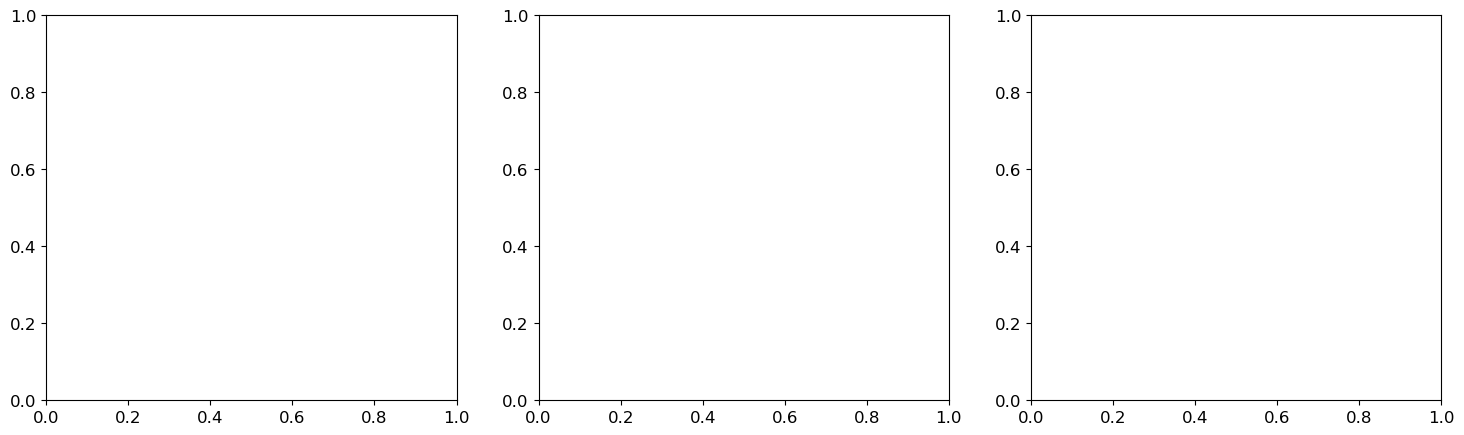

In [10]:
# Prepare data for visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_true_grid = y_true.reshape(X1_grid.shape)
y_pred_grid = y_pred.reshape(X1_grid.shape)
abs_error_grid = abs_error.reshape(X1_grid.shape)

In [11]:
# WDDEGP Prediction
c1 = axes[0].contourf(X1_grid, X2_grid, y_pred_grid, levels=50, cmap="viridis")
axes[0].scatter(X_train[:, 0], X_train[:, 1],
                c="red", edgecolor="k", s=50, zorder=5, label="Training points")
axes[0].set_title("WDDEGP Prediction")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].legend()
fig.colorbar(c1, ax=axes[0])

In [12]:
# True Function
c2 = axes[1].contourf(X1_grid, X2_grid, y_true_grid, levels=50, cmap="viridis")
axes[1].scatter(X_train[:, 0], X_train[:, 1],
                c="red", edgecolor="k", s=50, zorder=5)
axes[1].set_title("True Function (Six-Hump Camel)")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
fig.colorbar(c2, ax=axes[1])

In [13]:
# Absolute Error
c3 = axes[2].contourf(X1_grid, X2_grid, abs_error_grid, levels=50, cmap="magma")
axes[2].scatter(X_train[:, 0], X_train[:, 1],
                c="red", edgecolor="k", s=50, zorder=5)
axes[2].set_title(f"Absolute Error (NRMSE={nrmse:.4f})")
axes[2].set_xlabel("$x_1$")
axes[2].set_ylabel("$x_2$")
fig.colorbar(c3, ax=axes[2])

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max error: {abs_error.max():.6f}")

<Figure size 640x480 with 0 Axes>


Final Results:
  NRMSE: 0.004594
  Max error: 0.038933
